# Solution 2 for exercise 3
***

## Task 1

### a)
***

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn.linear_model as skm

from ISLP import load_data
from ISLP.models import ModelSpec as MS, summarize
from ISLP.transforms import BSpline

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans, AgglomerativeClustering

from scipy.optimize import minimize_scalar
from scipy.cluster.hierarchy import dendrogram, cut_tree
from ISLP.cluster import compute_linkage

In [19]:
#Loading data
College = load_data('College')
xdata = College[['Apps', 'Accept', 'Top10perc', 'Outstate', 'perc.alumni', 'Expend']]
xdata.head()

,Apps,Accept,Top10perc,Outstate,perc.alumni,Expend
0,1660,1232,23,7440,12,7041
1,2186,1924,16,12280,16,10527
2,1428,1097,22,11250,30,8735
3,417,349,60,12960,37,19016
4,193,146,16,7560,2,10922


In [20]:
n = len(College)
np.random.seed(123)
train_idx = np.random.choice(n, size = n // 2, replace = False)

mask = np.ones(n, dtype = bool)
mask[train_idx] = False

train = xdata.iloc[train_idx]
test = xdata.iloc[mask]

In [21]:
Xtrain = train.iloc[:, 1:].values
ytrain = train.iloc[:, 0].values
ridge = skm.Ridge(alpha = 10000)
ridge.fit(Xtrain, ytrain)
beta_ridge = ridge.coef_

In [22]:
Xtrain_with_const = sm.add_constant(Xtrain)
ols = sm.OLS(ytrain, Xtrain_with_const).fit()
ridge_coef = np.concatenate(([ridge.intercept_], ridge.coef_))
coef_comparison = np.column_stack((ols.params, ridge_coef))
coef_comparison = pd.DataFrame(coef_comparison, columns = ['OLS', 'Ridge'])

print(coef_comparison)

          OLS       Ridge
0 -552.246063 -577.739488
1    1.345925    1.353613
2   34.401643   29.486275
3   -0.074912   -0.072937
4   -6.531208   -4.187723
5    0.083093    0.090445


### c)
***

In [28]:
lambdas = np.logspace(-6, 6, 100)

ridge_cv = skm.RidgeCV(alphas = lambdas, cv = 5)
ridge_cv.fit(Xtrain, ytrain)

lambda_ridge = ridge_cv.alpha_
ridge_opt = skm.Ridge(alpha = lambda_ridge)
ridge_opt.fit(Xtrain, ytrain)

print(f"Optimal lambda for Ridge: {lambda_ridge:.4f}")

lasso_cv = skm.LassoCV(alphas = lambdas, cv = 5)
lasso_cv.fit(Xtrain, ytrain)

lambda_lasso = lasso_cv.alpha_
lasso_opt = skm.Lasso(alpha = lambda_lasso)
lasso_opt.fit(Xtrain, ytrain)

print(f"Optimal lambda for Lasso: {lambda_lasso}")

Optimal lambda for Ridge: 2848.0359
Optimal lambda for Lasso: 1e-06


### d)
***

In [32]:
#Comparison
ridge_coef = np.concatenate(([ridge_opt.intercept_], ridge_opt.coef_))
lasso_coef = np.concatenate(([lasso_opt.intercept_], lasso_opt.coef_))
coef_comparison = np.column_stack((ols.params, ridge_coef, lasso_coef))
coef_comparison = pd.DataFrame(coef_comparison,columns=['OLS','Ridge','Lasso'])
print(coef_comparison)

          OLS       Ridge       Lasso
0 -552.246063 -560.804687 -552.246063
1    1.345925    1.348448    1.345925
2   34.401643   32.830520   34.401643
3   -0.074912   -0.074391   -0.074912
4   -6.531208   -5.708781   -6.531208
5    0.083093    0.085417    0.083093


### e)
***

In [36]:
ytest = train.iloc[:,0]
Xtest = train.iloc[:,1:]
Xtest_const = sm.add_constant(Xtest)
olspred = ols.predict(Xtest_const)
ridgepred = ridge_opt.predict(Xtest)
lassopred = lasso_opt.predict(Xtest)
MSEols = sum((ytest-olspred)**2)
MSErid = sum((ytest-ridgepred)**2)
MSElas = sum((ytest-lassopred)**2)
print("MSE for OLS: ",round(MSEols,1))
print("MSE for Ridge: ",round(MSErid,1))
print("MSE for Lasso: ",round(MSElas,1))

MSE for OLS:  442149028.0
MSE for Ridge:  442309293.5
MSE for Lasso:  442149028.0


/opt/anaconda3/envs/BAN404/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/BAN404/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(


## Task 2
***

In [39]:
x = np.array([1, 2, 3, 4, 5, 6, 7, 8]).astype(int)
y = np.array([7.83, 6.99, 2.57, -2.01, -0.84, 8.30, 5.15, 16.14]).astype(float)

### b)
***

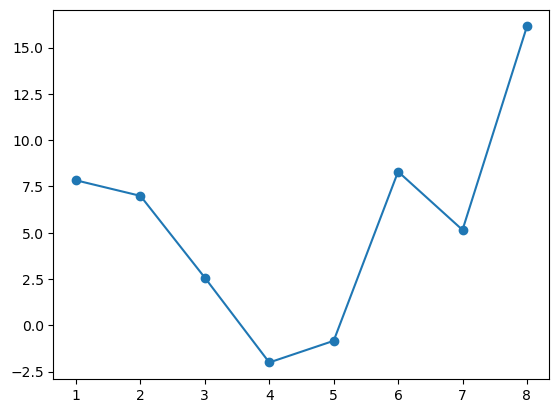

In [51]:
X = np.column_stack([x ** k for k in range (1, 8)])

X_const = sm.add_constant(X)
ols = sm.OLS(y, X_const).fit()

y_pred = ols.predict()

plt.scatter(x, y)
plt.plot(x, y_pred)
plt.show()